# Credit Card Approval Prediction

## Data Preprocessing

### Objective

The objective of this notebook is to clean, transform, and prepare the credit card approval dataset for machine learning. This includes handling missing values, removing duplicates, creating the target variable, merging datasets, encoding categorical features, scaling numerical features, and generating the final processed dataset.

In [30]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

#Load Dataset

In [31]:
application_df = pd.read_csv("../dataset/application_record.csv")
credit_df = pd.read_csv("../dataset/credit_record.csv")

#Missing Values

In [32]:
application_df.isnull().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

#Handle Missing Values

In [33]:
application_df["OCCUPATION_TYPE"].fillna("Unknown", inplace=True)

application_df.isnull().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

#Remove Duplicates

In [34]:
application_df.drop_duplicates(inplace=True)
credit_df.drop_duplicates(inplace=True)

print(application_df.duplicated().sum())
print(credit_df.duplicated().sum())

0
0


## Create Target Variable

The application dataset does not contain a target label indicating whether an applicant should be approved or rejected. Therefore, a binary target variable is created using the credit history records.

Applicants with severe overdue payments (STATUS values 3, 4, or 5) are labeled as high risk (Rejected = 1). Applicants with all other statuses (X, C, 0, 1, and 2) are labeled as low risk (Approved = 0).

In [35]:
credit_df["TARGET"] = credit_df["STATUS"].apply(
    lambda x: 1 if x in ["3", "4", "5"] else 0
)

In [36]:
credit_df.head()

,ID,MONTHS_BALANCE,STATUS,TARGET
0,5001711,0,X,0
1,5001711,-1,0,0
2,5001711,-2,0,0
3,5001711,-3,0,0
4,5001712,0,C,0


In [37]:
credit_df["TARGET"].value_counts()

TARGET
0    1046339
1       2236
Name: count, dtype: int64

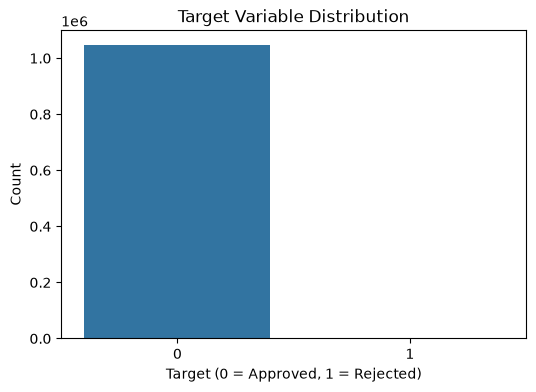

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="TARGET", data=credit_df)

plt.title("Target Variable Distribution")
plt.xlabel("Target (0 = Approved, 1 = Rejected)")
plt.ylabel("Count")

plt.show()

## Merge Datasets

The credit history dataset contains multiple records for each applicant because repayment history is stored monthly. Before merging with the application dataset, the credit records are grouped by applicant ID. If an applicant has at least one high-risk credit record, the applicant is labeled as high risk (TARGET = 1). Otherwise, the applicant is labeled as low risk (TARGET = 0).

The aggregated target labels are then merged with the application dataset using the common ID column.

In [39]:
credit_target = credit_df.groupby("ID")["TARGET"].max().reset_index()

In [40]:
credit_target.head()

,ID,TARGET
0,5001711,0
1,5001712,0
2,5001713,0
3,5001714,0
4,5001715,0


In [41]:
df = application_df.merge(credit_target, on="ID", how="inner")

In [42]:
print("Merged Dataset Shape:", df.shape)

Merged Dataset Shape: (36457, 19)


In [43]:
df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0


#Check Missing Values Again

In [44]:
df.isnull().sum()

ID                         0
CODE_GENDER                0
FLAG_OWN_CAR               0
FLAG_OWN_REALTY            0
CNT_CHILDREN               0
AMT_INCOME_TOTAL           0
NAME_INCOME_TYPE           0
NAME_EDUCATION_TYPE        0
NAME_FAMILY_STATUS         0
NAME_HOUSING_TYPE          0
DAYS_BIRTH                 0
DAYS_EMPLOYED              0
FLAG_MOBIL                 0
FLAG_WORK_PHONE            0
FLAG_PHONE                 0
FLAG_EMAIL                 0
OCCUPATION_TYPE        11323
CNT_FAM_MEMBERS            0
TARGET                     0
dtype: int64

#Fill Missing Values

In [45]:
df["OCCUPATION_TYPE"] = df["OCCUPATION_TYPE"].fillna("Unknown")

df.isnull().sum()

ID                     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
DAYS_BIRTH             0
DAYS_EMPLOYED          0
FLAG_MOBIL             0
FLAG_WORK_PHONE        0
FLAG_PHONE             0
FLAG_EMAIL             0
OCCUPATION_TYPE        0
CNT_FAM_MEMBERS        0
TARGET                 0
dtype: int64

#Encode Categorical Features

In [46]:
categorical_columns = df.select_dtypes(include="object").columns

print(categorical_columns)

Index(['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE',
       'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
       'OCCUPATION_TYPE'],
      dtype='str')


In [47]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

### Observation

All categorical features have been successfully converted into numerical values using Label Encoding. The dataset now contains only numerical values, making it suitable for training machine learning classification models such as Logistic Regression, Decision Tree, Random Forest, and XGBoost.

# Feature Scaling

Feature scaling standardizes numerical features so that they have a similar range. This improves the performance of machine learning algorithms such as Logistic Regression and ensures that no single feature dominates due to its larger magnitude.

In [48]:
X = df.drop(["ID", "TARGET"], axis=1)

y = df["TARGET"]

In [49]:
from sklearn.preprocessing import StandardScaler

In [50]:
scaler = StandardScaler()

In [51]:
X_scaled = scaler.fit_transform(X)

In [52]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

In [53]:
X_scaled.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,1.425224,1.278126,0.698338,-0.579661,2.365845,0.923758,-1.563576,-1.433026,2.855131,0.945169,-0.463532,0.0,1.853127,-0.646578,-0.313952,1.139980,-0.217680
1,1.425224,1.278126,0.698338,-0.579661,2.365845,0.923758,-1.563576,-1.433026,2.855131,0.945169,-0.463532,0.0,1.853127,-0.646578,-0.313952,1.139980,-0.217680
2,1.425224,1.278126,0.698338,-0.579661,-0.728827,0.923758,0.673104,-0.385405,-0.297250,-1.309091,-0.438774,0.0,-0.539628,-0.646578,-0.313952,0.961973,-0.217680
3,-0.701644,-0.782396,0.698338,-0.579661,0.818509,-1.383035,0.673104,1.709838,-0.297250,-0.746300,-0.452700,0.0,-0.539628,1.546603,3.185203,0.605958,-1.314564
4,-0.701644,-0.782396,0.698338,-0.579661,0.818509,-1.383035,0.673104,1.709838,-0.297250,-0.746300,-0.452700,0.0,-0.539628,1.546603,3.185203,0.605958,-1.314564


# Train-Test Split

The dataset is divided into training and testing sets. The training data is used to train the machine learning models, while the testing data is used to evaluate their performance on unseen data.

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Features: (29165, 17)
Testing Features : (7292, 17)
Training Labels : (29165,)
Testing Labels  : (7292,)


# Save Processed Data

In [55]:
processed_df = X_scaled.copy()

processed_df["TARGET"] = y.values

In [56]:
processed_df.to_csv(
    "../dataset/processed_credit_data.csv",
    index=False
)

In [57]:
processed_df.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,1.425224,1.278126,0.698338,-0.579661,2.365845,0.923758,-1.563576,-1.433026,2.855131,0.945169,-0.463532,0.0,1.853127,-0.646578,-0.313952,1.139980,-0.217680,0
1,1.425224,1.278126,0.698338,-0.579661,2.365845,0.923758,-1.563576,-1.433026,2.855131,0.945169,-0.463532,0.0,1.853127,-0.646578,-0.313952,1.139980,-0.217680,0
2,1.425224,1.278126,0.698338,-0.579661,-0.728827,0.923758,0.673104,-0.385405,-0.297250,-1.309091,-0.438774,0.0,-0.539628,-0.646578,-0.313952,0.961973,-0.217680,0
3,-0.701644,-0.782396,0.698338,-0.579661,0.818509,-1.383035,0.673104,1.709838,-0.297250,-0.746300,-0.452700,0.0,-0.539628,1.546603,3.185203,0.605958,-1.314564,0
4,-0.701644,-0.782396,0.698338,-0.579661,0.818509,-1.383035,0.673104,1.709838,-0.297250,-0.746300,-0.452700,0.0,-0.539628,1.546603,3.185203,0.605958,-1.314564,0


# Conclusion

The preprocessing stage successfully prepared the credit card approval dataset for machine learning.

### Tasks Completed

- Missing values were handled.
- Duplicate records were removed.
- A binary target variable was created from the credit history dataset.
- Application and credit datasets were merged using the applicant ID.
- Categorical variables were encoded using Label Encoding.
- Numerical features were standardized using StandardScaler.
- The dataset was split into training and testing sets.
- The processed dataset was saved for use in model training.

The dataset is now ready for building and evaluating classification models.

In [ ]:
import os
print(os.path.exists("../models/encoder.pkl"))

True
